In [1]:
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 6.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 6.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 6.0 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 6.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 6.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 6.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----- ------------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)


D:\Python\python.exe


In [3]:
import pandas as pd
# SOURCING THE RAW DATA
data = {'Employee_ID': [101, 102, 103, 104, 105],
        'Role': ['Data Analyst', 'Data Scientist', 'Data Analyst', 'Data Engineer', 'Data Analyst'],
        'Experience_Level': ['Junior', 'Senior', 'Junior', 'Senior', 'Mid'],
        'Annual_Salary_USD': [65000, 120000, None, 135000, 85000]
        }
df = pd.DataFrame(data)
print("---Raw Data---")
print(df)

---Raw Data---
   Employee_ID            Role Experience_Level  Annual_Salary_USD
0          101    Data Analyst           Junior            65000.0
1          102  Data Scientist           Senior           120000.0
2          103    Data Analyst           Junior                NaN
3          104   Data Engineer           Senior           135000.0
4          105    Data Analyst              Mid            85000.0


In [4]:
# We have a missing value (NaN) at index 2. To fix this without throwing away the row, 
# we will replace the missing value with the median salary of the other Junior roles(which is 65000).

#Calculate median for junior roles
junior_median = df[df['Experience_Level'] == 'Junior']['Annual_Salary_USD'].median()

#Fill the missing value
df['Annual_Salary_USD'] = df['Annual_Salary_USD']. fillna(junior_median)

#Convert salary to integers for cleaner presentatian
df['Annual_Salary_USD']=df['Annual_Salary_USD'].astype(int)

print("--- Cleaned Data ---")
print(df)


--- Cleaned Data ---
   Employee_ID            Role Experience_Level  Annual_Salary_USD
0          101    Data Analyst           Junior              65000
1          102  Data Scientist           Senior             120000
2          103    Data Analyst           Junior              65000
3          104   Data Engineer           Senior             135000
4          105    Data Analyst              Mid              85000


In [5]:
#STEP 3: DATA ANALYSIS & AGGREGTION
# Now we group the data by Experience_level to find the average(mean) salary for each tier

#Group by experience level and calculate the average salary
avg_salary_by_experience = df.groupby('Experience_Level')['Annual_Salary_USD'].mean().reset_index()

#Sort by salary to make it logical
avg_salary_by_experience = avg_salary_by_experience.sort_values(by='Annual_Salary_USD')

print("---Average Salaryby Experience Level ---")
print(avg_salary_by_experience)

---Average Salaryby Experience Level ---
  Experience_Level  Annual_Salary_USD
0           Junior            65000.0
1              Mid            85000.0
2           Senior           127500.0


In [6]:
#STEP 4: FINDING SPECIFIC INSIGHTS (THE "TOP EARNER")
#Let's filter the data to find out exactly who makes the most money in this dataset.

#Find the row with the maximum salary
top_earner = df[df['Annual_Salary_USD'] == df['Annual_Salary_USD'].max()]
print("---TOP EARNER DETAILS---")
print(top_earner)


---TOP EARNER DETAILS---
   Employee_ID           Role Experience_Level  Annual_Salary_USD
3          104  Data Engineer           Senior             135000


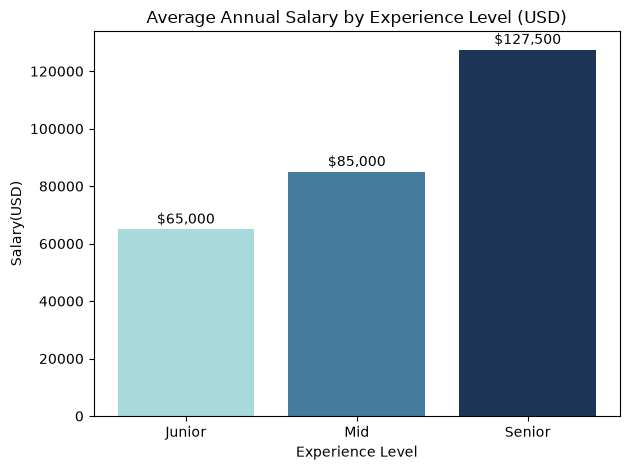

In [10]:
#STEP 6: DATA VISUALIZATION CODE
import pandas as pd
import matplotlib.pyplot as plt

#1. Recreate the cleaned dataset
data = {'Employee_ID': [101, 102, 103, 104, 105],
        'Role': ['Data Analyst', 'Data Scientist', 'Data Analyst', 'Data Engineer', 'Data Analyst'],
        'Experience_Level': ['Junior', 'Senior', 'Junior', 'Senior', 'Mid'],
        'Annual_Salary_USD': [65000, 120000, 65000, 135000, 85000]
        }
df = pd.DataFrame(data)

#2.Group data and calculate the average salary
avg_salary = df.groupby('Experience_Level')['Annual_Salary_USD'].mean().reset_index()

#3.Sort logically by Experience order
order = ['Junior','Mid','Senior']
avg_salary['Experience_Level'] = pd.Categorical(avg_salary['Experience_Level'], categories = order, ordered = True)
avg_salary = avg_salary.sort_values('Experience_Level')

#4. Create the bar chart
plt.bar(avg_salary['Experience_Level'], avg_salary['Annual_Salary_USD'], color=['#A8DADC', '#457B9D', '#1D3557'])
plt.title('Average Annual Salary by Experience Level (USD)')
plt.xlabel('Experience Level')
plt.ylabel('Salary(USD)')

#5. Add data labels above the bars
for index, value in enumerate(avg_salary['Annual_Salary_USD']): 
    plt.text(index, value + 2000, f"${value:,.0f}", ha = 'center', fontsize=10)

#6.Save the visualization
plt.tight_layout()
plt.savefig('average_salary_by_experience.png')
